In [8]:
import numpy as np
from pandas import DataFrame, read_excel
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import confusion_matrix

In [9]:
filename = "../DataBase/DataCollection.xlsx"
dataset: DataFrame = read_excel(filename, sheet_name="895 Records")
print(dataset.shape)

(895, 40)


`Variables Encoding`

In [ ]:
dissolve_encoding: dict[str, int] = {"NO": 0,"YES": 1}
sample_type_enconding: dict[str, int] = {"pellet": 0, "waste": 1, "fiber": 2, "film": 3, "powder": 4}

encoding: dict[str, dict[str, int]] = {
    "Dissolution": dissolve_encoding,
    "Sample type": sample_type_enconding
}
df: DataFrame = dataset.replace(encoding, inplace=False)

`Variables Normalization`

In [11]:
df = df.drop(columns=["Polymer_ID", "Solvent_ID", "Polymer", "Solvent"])

X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

X_log = np.log1p(X)
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
X_scaled = min_max_scaler.fit_transform(X_log)

df_log_minmax = DataFrame(X_scaled, columns = X.columns, index= X.index)
df_log_minmax["Dissolution"] = y

In [12]:
target = 'Dissolution'
X = df_log_minmax.drop(columns=target)
y = df_log_minmax[target]

`Cross-Validation` - Hyperparameter Search

In [13]:
# Hyperparameters to Evaluate
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.75],
    'criterion': ['entropy', 'gini'],
    'splitter': ['best'],
    'max_leaf_nodes' : [None, 10, 20, 50, 100],
    'min_impurity_decrease': [0.0, 0.0001, 0.001, 0.01],
}

In [14]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []


for i in range(5):  
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i}\n{'='*30}")

    grid_search = GridSearchCV(DecisionTreeClassifier(random_state=i), param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_val, y_val)
    best_params = grid_search.best_params_
    best_params_list.append(best_params)

    model = DecisionTreeClassifier(**best_params, random_state=i)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Best otimization:  {best_params}")
    print(f"Accuracy - Train:     {acc_train:.3f}")
    print(f"Accuracy - Validation:  {acc_val:.3f}")
    print(f"Accuracy - Test:      {acc_test:.3f}")

print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.3f}, Standard Deviation = {np.std(acc_train_list):.3f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.3f}, Standard Deviation = {np.std(acc_val_list):.3f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.3f}, Standard Deviation = {np.std(acc_test_list):.3f}")


Starting Iteration 0
Best otimization:  {'criterion': 'gini', 'max_depth': 6, 'max_features': 0.75, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'splitter': 'best'}
Accuracy - Train:     0.861
Accuracy - Validation:  0.769
Accuracy - Test:      0.837

Starting Iteration 1
Best otimization:  {'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.5, 'max_leaf_nodes': 10, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy - Train:     0.789
Accuracy - Validation:  0.791
Accuracy - Test:      0.822

Starting Iteration 2
Best otimization:  {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy - Train:     0.885
Accuracy - Validation:  0.813
Accuracy - Test:      0.830

Starting Iteration 3
Best otimization:  {'criterion': 'gini', 'max_depth': 

`Cross-Validation` - Manual Fine-Tunning

In [15]:
#random_state = np.random.randint(0, 2**32)
#print(random_state)
random_state = 862343415

In [16]:
# Hyperparameters to Evaluate across 5 different data splits
param_grid = {
    'criterion': 'gini',
    'max_depth': 6,
    'max_features': None,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'splitter': 'best'
}

In [17]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []

for i in range(5): 
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i+1}\n{'='*30}")

    dt_model = DecisionTreeClassifier(**param_grid, random_state = random_state)
    dt_model.fit(X_train, y_train)

    y_val_pred = dt_model.predict(X_val)
    y_train_pred = dt_model.predict(X_train)
    y_test_pred = dt_model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Running parameters:  {param_grid}")
    print(f"Accuracy - Train:     {acc_train:.4f}")
    print(f"Accuracy - Validation:  {acc_val:.4f}")
    print(f"Accuracy - Test:      {acc_test:.4f}")

print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.4f}, Standard Deviation = {np.std(acc_train_list):.4f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.4f}, Standard Deviation = {np.std(acc_val_list):.4f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.4f}, Standard Deviation = {np.std(acc_test_list):.4f}")


Starting Iteration 1
Running parameters:  {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy - Train:     0.8866
Accuracy - Validation:  0.8731
Accuracy - Test:      0.8815

Starting Iteration 2
Running parameters:  {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy - Train:     0.8882
Accuracy - Validation:  0.7985
Accuracy - Test:      0.8519

Starting Iteration 3
Running parameters:  {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy - Train:     0.8850
Accuracy - Validation:  0.8134
Accuracy - Test:      0.8296

Starting Iteration 4
Running parameters:  {'criterion': 'gin

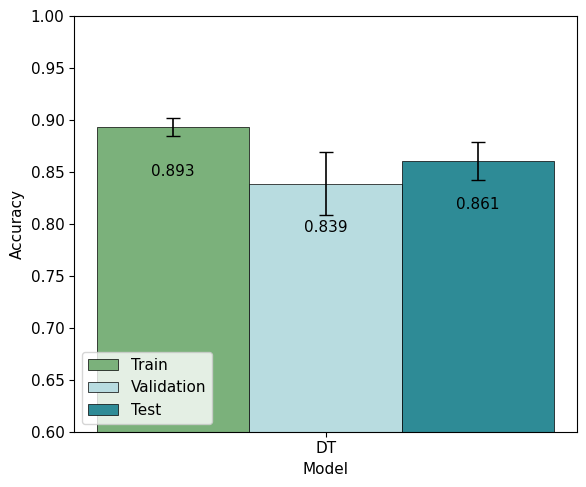

In [ ]:
# Final results
means = [0.8930, 0.8388, 0.8607]
stds = [0.0089, 0.0304, 0.0184]
labels = ['Train', 'Validation', 'Test']
colors = ['#7BB17B', '#B8DCE0', '#2E8B96'] 

plt.rcParams.update({'font.size': 11})
x_center = 0
width = 0.25
positions = [x_center - width, x_center, x_center + width]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(positions, means, width, yerr=stds, color=colors,
              edgecolor='black', linewidth=0.5,
              capsize=5, error_kw={'elinewidth': 1.2, 'ecolor': 'black'})

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean - 0.035,
            f'{mean:.3f}', ha='center', va='top', fontsize=11, color='black')

ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks([x_center])
ax.set_xticklabels(['DT'], fontsize=11)
ax.tick_params(axis='both', labelsize=11)


legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec='black', lw=0.5) for c in colors]
ax.legend(legend_handles, labels, loc='lower left', frameon=True, fontsize=11)


ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

`XAI DT` - Inherent Tree Structure

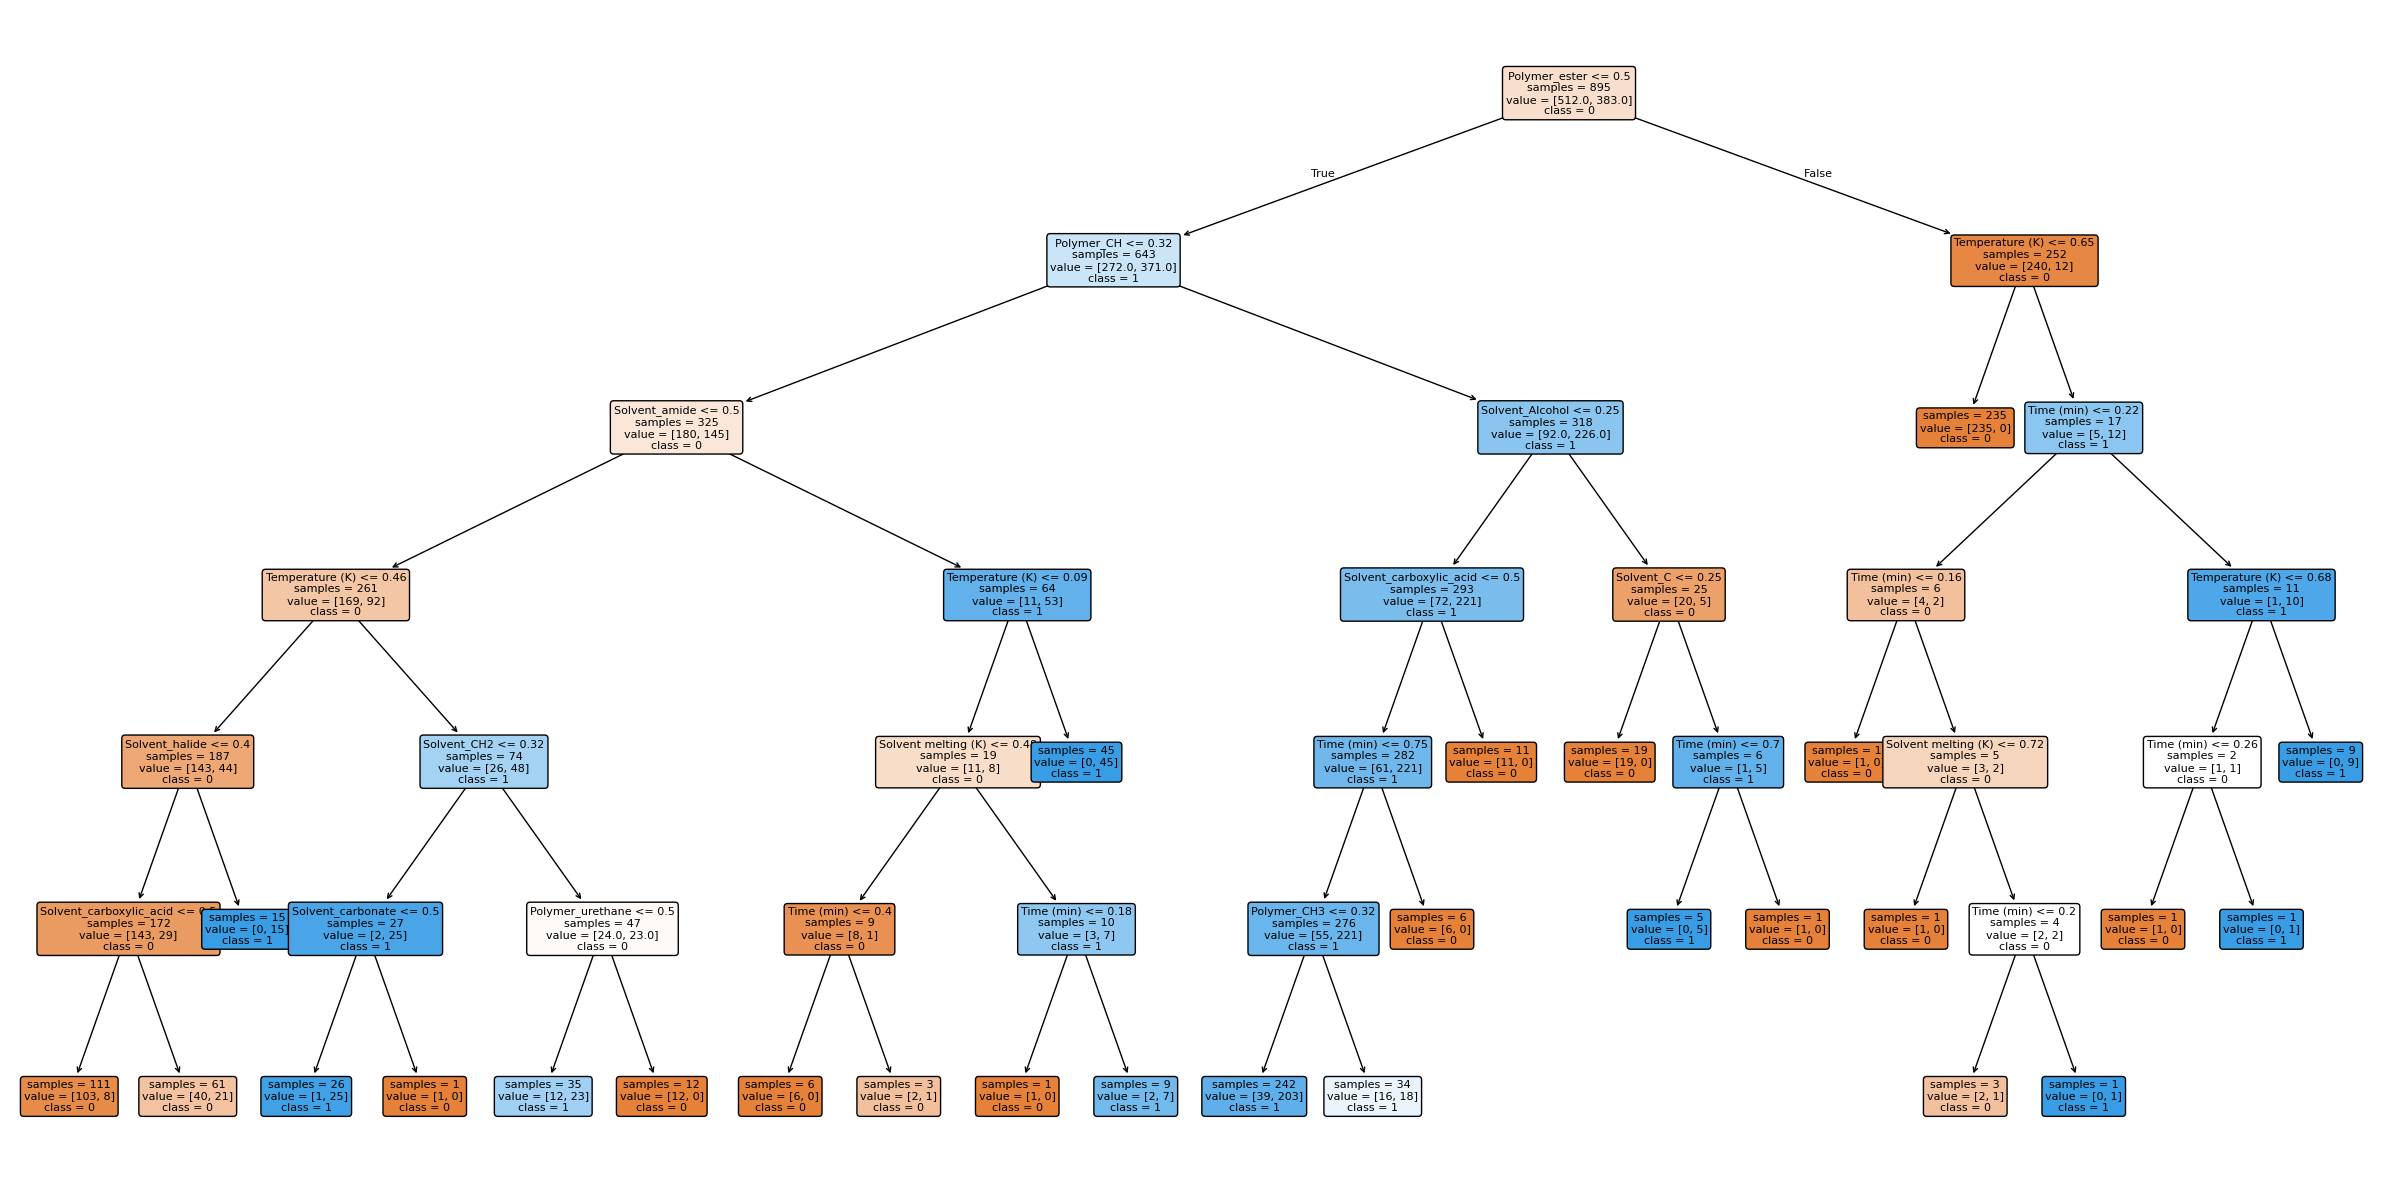

Confusion Matrix Results:
TP: 352
TN: 442
FP: 70
FN: 31


In [18]:
dt_model.fit(X, y)
feature_names_input = X.columns.tolist()
st_labels_input = [str(label) for label in sorted(y.unique())]

max_depth2show = 6
plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    max_depth=max_depth2show,
    feature_names=feature_names_input,
    class_names=st_labels_input,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=8,
)

plt.axis("off")
plt.tight_layout()
plt.show()

y_pred = dt_model.predict(X)

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

print("Confusion Matrix Results:")
print(f"TP: {tp}")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")

`XAI SHAP` - Feature Relative Importance Plot

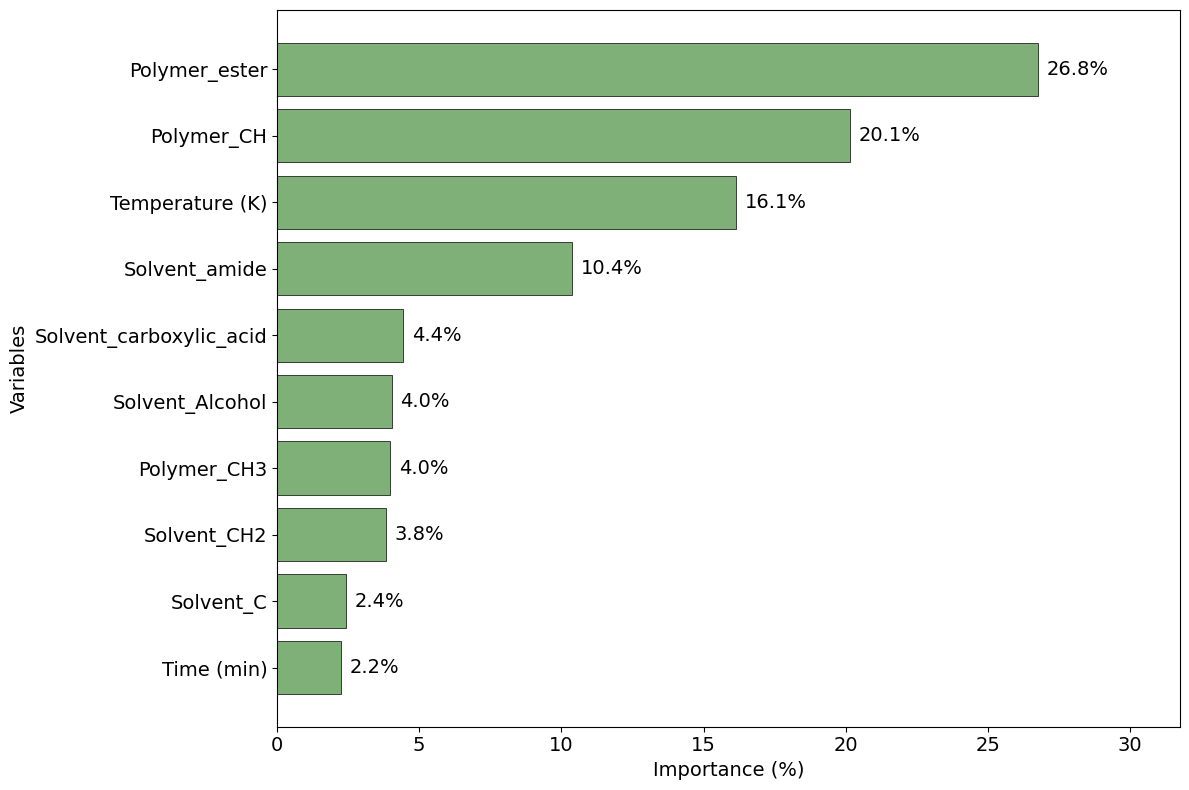

In [25]:
background = shap.sample(X)
explainer = shap.TreeExplainer(dt_model, data=background, model_output="probability")
explanation = explainer(X)
shap_values_class1 = explanation[:, :, 1]

mean_shap = np.mean(np.abs(shap_values_class1.values), axis=0)
importance_features_percentage = (mean_shap / np.sum(mean_shap)) * 100

max_display = 10

data = sorted(zip(feature_names_input, importance_features_percentage), key=lambda x: x[1], reverse=False)
data = data[-max_display:]
sorted_names, sorted_values = zip(*data)

fig, ax = plt.subplots(figsize=(12, 8))

bar_color = '#7eb078' 
bars = ax.barh(sorted_names, sorted_values, color=bar_color, edgecolor='black', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("Importance (%)", fontsize=14)
ax.set_ylabel("Variables", fontsize=14)
ax.set_xlim(0, max(sorted_values) + 5) 

plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=600, bbox_inches="tight")
plt.show()